In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

In [3]:
data_path = Path(
    "../../part2_python/data/processed/traffic_features.csv"
)

df = pd.read_csv(
    data_path,
    parse_dates=["date_time"]
)

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,month,...,Weather_Haze,Weather_Mist,Weather_Rain,Weather_Smoke,Weather_Snow,Weather_Squall,Weather_Thunderstorm,Temp_Scaled,Clouds_Scaled,Congestion_Category
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,10,...,0,0,0,0,0,0,0,0.673215,0.40,High
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,...,0,0,0,0,0,0,0,0.689412,0.75,Medium
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,10,...,0,0,0,0,0,0,0,0.692711,0.90,Medium
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,10,...,0,0,0,0,0,0,0,0.700960,0.90,High
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,10,...,0,0,0,0,0,0,0,0.716107,0.75,Medium


In [4]:
df.shape

(48187, 30)

In [5]:
df.columns.tolist()

['holiday',
 'temp',
 'rain_1h',
 'snow_1h',
 'clouds_all',
 'weather_main',
 'weather_description',
 'date_time',
 'traffic_volume',
 'month',
 'Hour',
 'Day_of_Week',
 'Weekend_Indicator',
 'Hour_sin',
 'Hour_cos',
 'Rain_Indicator',
 'Weather_Clear',
 'Weather_Clouds',
 'Weather_Drizzle',
 'Weather_Fog',
 'Weather_Haze',
 'Weather_Mist',
 'Weather_Rain',
 'Weather_Smoke',
 'Weather_Snow',
 'Weather_Squall',
 'Weather_Thunderstorm',
 'Temp_Scaled',
 'Clouds_Scaled',
 'Congestion_Category']

In [6]:
df["Congestion_Category"].value_counts()

Congestion_Category
Medium    24103
Low       12047
High      12037
Name: count, dtype: int64

In [7]:
q1, q2, q3 = df["traffic_volume"].quantile(
    [0.25, 0.50, 0.75]
).values

print("Q1:", q1)
print("Q2:", q2)
print("Q3:", q3)

Q1: 1192.5
Q2: 3379.0
Q3: 4933.0


In [8]:
def bucket(v):
    if v <= q1:
        return "Low"
    elif v <= q2:
        return "Medium"
    elif v <= q3:
        return "High"
    return "Severe"


df["congestion_category"] = df["traffic_volume"].apply(bucket)

df["congestion_category"].value_counts()

congestion_category
High      12054
Medium    12049
Low       12047
Severe    12037
Name: count, dtype: int64

In [9]:
print("weather_main categories:")
print(sorted(df["weather_main"].dropna().unique()))

print("\nweather_description categories:")
print(sorted(df["weather_description"].dropna().unique()))

weather_main categories:
['Clear', 'Clouds', 'Drizzle', 'Fog', 'Haze', 'Mist', 'Rain', 'Smoke', 'Snow', 'Squall', 'Thunderstorm']

weather_description categories:
['SQUALLS', 'Sky is Clear', 'broken clouds', 'drizzle', 'few clouds', 'fog', 'freezing rain', 'haze', 'heavy intensity drizzle', 'heavy intensity rain', 'heavy snow', 'light intensity drizzle', 'light intensity shower rain', 'light rain', 'light rain and snow', 'light shower snow', 'light snow', 'mist', 'moderate rain', 'overcast clouds', 'proximity shower rain', 'proximity thunderstorm', 'proximity thunderstorm with drizzle', 'proximity thunderstorm with rain', 'scattered clouds', 'shower drizzle', 'shower snow', 'sky is clear', 'sleet', 'smoke', 'snow', 'thunderstorm', 'thunderstorm with drizzle', 'thunderstorm with heavy rain', 'thunderstorm with light drizzle', 'thunderstorm with light rain', 'thunderstorm with rain', 'very heavy rain']


In [10]:
SEVERE_WEATHER = [
    "Thunderstorm",
    "Squall",
    "Snow"
]

LOW_VISIBILITY_WEATHER = [
    "Fog",
    "Mist",
    "Haze",
    "Smoke"
]

df["is_low_visibility"] = (
    df["weather_main"]
    .isin(LOW_VISIBILITY_WEATHER)
    .astype(int)
)

print(
    df["is_low_visibility"].value_counts()
)

is_low_visibility
0    39946
1     8241
Name: count, dtype: int64


In [11]:
high_congestion = df["congestion_category"].isin(
    ["High", "Severe"]
)

risky_weather = (
    df["weather_main"].isin(SEVERE_WEATHER)
    | (df["is_low_visibility"] == 1)
)

df["high_risk"] = (
    high_congestion & risky_weather
).astype(int)

df["high_risk"].value_counts()

high_risk
0    42749
1     5438
Name: count, dtype: int64

In [12]:
df["Day_of_Week_Num"] = df["date_time"].dt.dayofweek

df["Day_sin"] = np.sin(
    2 * np.pi * df["Day_of_Week_Num"] / 7
)

df["Day_cos"] = np.cos(
    2 * np.pi * df["Day_of_Week_Num"] / 7
)

df["Holiday_Flag"] = (
    df["holiday"]
    .fillna("None")
    .ne("None")
    .astype(int)
)

df[
    [
        "date_time",
        "Day_of_Week",
        "Day_of_Week_Num",
        "Day_sin",
        "Day_cos",
        "Holiday_Flag"
    ]
].head()

,date_time,Day_of_Week,Day_of_Week_Num,Day_sin,Day_cos,Holiday_Flag
0,2012-10-02 09:00:00,Tuesday,1,0.781831,0.62349,0
1,2012-10-02 10:00:00,Tuesday,1,0.781831,0.62349,0
2,2012-10-02 11:00:00,Tuesday,1,0.781831,0.62349,0
3,2012-10-02 12:00:00,Tuesday,1,0.781831,0.62349,0
4,2012-10-02 13:00:00,Tuesday,1,0.781831,0.62349,0


In [13]:
weather_columns = [
    col for col in df.columns
    if col.startswith("Weather_")
]

weather_columns

['Weather_Clear',
 'Weather_Clouds',
 'Weather_Drizzle',
 'Weather_Fog',
 'Weather_Haze',
 'Weather_Mist',
 'Weather_Rain',
 'Weather_Smoke',
 'Weather_Snow',
 'Weather_Squall',
 'Weather_Thunderstorm']

In [14]:
feature_columns = [
    # Time features
    "Hour",
    "Day_of_Week_Num",
    "Weekend_Indicator",

    # Cyclical time features
    "Hour_sin",
    "Hour_cos",
    "Day_sin",
    "Day_cos",

    # Holiday
    "Holiday_Flag",

    # Numerical weather features
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
] + weather_columns

X = df[feature_columns].copy()

print("Number of features:", X.shape[1])
print("Dataset shape:", X.shape)
print("\nMissing values:")
print(X.isna().sum().sum())

Number of features: 23
Dataset shape: (48187, 23)

Missing values:
0


In [15]:
# Classification target
y_class = df["high_risk"].copy()

# Regression target
y_reg = df["traffic_volume"].copy()

print("Classification target:")
print(y_class.value_counts())

print("\nRegression target summary:")
print(y_reg.describe())

Classification target:
high_risk
0    42749
1     5438
Name: count, dtype: int64

Regression target summary:
count    48187.000000
mean      3259.618134
std       1986.954465
min          0.000000
25%       1192.500000
50%       3379.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64


In [16]:
from sklearn.model_selection import train_test_split

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Training X shape:", X_train_class.shape)
print("Testing X shape:", X_test_class.shape)

print("\nTraining target:")
print(y_train_class.value_counts())

print("\nTesting target:")
print(y_test_class.value_counts())

Training X shape: (38549, 23)
Testing X shape: (9638, 23)

Training target:
high_risk
0    34199
1     4350
Name: count, dtype: int64

Testing target:
high_risk
0    8550
1    1088
Name: count, dtype: int64


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(
    X_train_class,
    y_train_class
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred_logistic = logistic_model.predict(X_test_class)

y_prob_logistic = logistic_model.predict_proba(
    X_test_class
)[:, 1]

logistic_accuracy = accuracy_score(
    y_test_class,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test_class,
    y_pred_logistic
)

logistic_recall = recall_score(
    y_test_class,
    y_pred_logistic
)

logistic_f1 = f1_score(
    y_test_class,
    y_pred_logistic
)

logistic_roc_auc = roc_auc_score(
    y_test_class,
    y_prob_logistic
)

print("Logistic Regression Results")
print("Accuracy:", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall:", round(logistic_recall, 4))
print("F1-score:", round(logistic_f1, 4))
print("ROC AUC:", round(logistic_roc_auc, 4))

Logistic Regression Results
Accuracy: 0.9653
Precision: 0.7736
Recall: 0.9798
F1-score: 0.8646
ROC AUC: 0.9937


In [19]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_class,
    y_train_class
)

print("Random Forest training completed.")

Random Forest training completed.


In [20]:
y_pred_rf = random_forest_model.predict(X_test_class)

y_prob_rf = random_forest_model.predict_proba(
    X_test_class
)[:, 1]

rf_accuracy = accuracy_score(
    y_test_class,
    y_pred_rf
)

rf_precision = precision_score(
    y_test_class,
    y_pred_rf
)

rf_recall = recall_score(
    y_test_class,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test_class,
    y_pred_rf
)

rf_roc_auc = roc_auc_score(
    y_test_class,
    y_prob_rf
)

print("Random Forest Results")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1-score:", round(rf_f1, 4))
print("ROC AUC:", round(rf_roc_auc, 4))

Random Forest Results
Accuracy: 0.9838
Precision: 0.9252
Recall: 0.932
F1-score: 0.9286
ROC AUC: 0.9965


In [21]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1-score": [
        logistic_f1,
        rf_f1
    ],
    "ROC AUC": [
        logistic_roc_auc,
        rf_roc_auc
    ]
})

classification_results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Logistic Regression,0.9653,0.7736,0.9798,0.8646,0.9937
1,Random Forest,0.9838,0.9252,0.9320,0.9286,0.9965


In [22]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression training X shape:", X_train_reg.shape)
print("Regression testing X shape:", X_test_reg.shape)

print("Regression training y shape:", y_train_reg.shape)
print("Regression testing y shape:", y_test_reg.shape)

Regression training X shape: (38549, 23)
Regression testing X shape: (9638, 23)
Regression training y shape: (38549,)
Regression testing y shape: (9638,)


In [23]:
from sklearn.linear_model import LinearRegression

linear_reg_model = LinearRegression()

linear_reg_model.fit(
    X_train_reg,
    y_train_reg
)

print("Linear Regression training completed.")

Linear Regression training completed.


In [24]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

y_pred_linear = linear_reg_model.predict(
    X_test_reg
)

linear_mae = mean_absolute_error(
    y_test_reg,
    y_pred_linear
)

linear_r2 = r2_score(
    y_test_reg,
    y_pred_linear
)

print("Linear Regression Results")
print("MAE:", round(linear_mae, 2))
print("R-squared:", round(linear_r2, 4))

Linear Regression Results
MAE: 813.47
R-squared: 0.726


In [25]:
from sklearn.ensemble import RandomForestRegressor

random_forest_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_reg.fit(
    X_train_reg,
    y_train_reg
)

print("Random Forest Regression training completed.")

Random Forest Regression training completed.


In [26]:
y_pred_rf_reg = random_forest_reg.predict(
    X_test_reg
)

rf_reg_mae = mean_absolute_error(
    y_test_reg,
    y_pred_rf_reg
)

rf_reg_r2 = r2_score(
    y_test_reg,
    y_pred_rf_reg
)

print("Random Forest Regression Results")
print("MAE:", round(rf_reg_mae, 2))
print("R-squared:", round(rf_reg_r2, 4))

Random Forest Regression Results
MAE: 271.26
R-squared: 0.9442


In [27]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor"
    ],
    "MAE": [
        linear_mae,
        rf_reg_mae
    ],
    "R-squared": [
        linear_r2,
        rf_reg_r2
    ]
})

regression_results.round(4)

,Model,MAE,R-squared
0,Linear Regression,813.4746,0.7260
1,Random Forest Regressor,271.2569,0.9442


In [28]:
weather_severity_map = {
    "Clear": 0,
    "Clouds": 1,
    "Drizzle": 2,
    "Rain": 3,
    "Snow": 4,
    "Mist": 4,
    "Haze": 4,
    "Smoke": 4,
    "Fog": 5,
    "Thunderstorm": 5,
    "Squall": 5
}

df["weather_severity"] = (
    df["weather_main"]
    .map(weather_severity_map)
)

df[
    [
        "weather_main",
        "weather_severity"
    ]
].drop_duplicates().sort_values(
    "weather_severity"
)

,weather_main,weather_severity
5,Clear,0
0,Clouds,1
179,Drizzle,2
164,Rain,3
268,Mist,4
271,Haze,4
16330,Smoke,4
662,Snow,4
528,Thunderstorm,5
296,Fog,5


In [29]:
from sklearn.preprocessing import StandardScaler

cluster_features = df[
    [
        "Hour",
        "weather_severity",
        "traffic_volume"
    ]
].copy()

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(
    cluster_features
)

print("Original shape:", cluster_features.shape)
print("Scaled shape:", cluster_scaled.shape)

Original shape: (48187, 3)
Scaled shape: (48187, 3)


In [30]:
from sklearn.cluster import KMeans

kmeans_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["traffic_cluster"] = kmeans_model.fit_predict(
    cluster_scaled
)

df["traffic_cluster"].value_counts().sort_index()

traffic_cluster
0    13340
1    22197
2    12650
Name: count, dtype: int64

In [31]:
cluster_summary = df.groupby(
    "traffic_cluster"
)[
    [
        "Hour",
        "weather_severity",
        "traffic_volume"
    ]
].mean()

cluster_summary.round(2)

,Hour,weather_severity,traffic_volume
traffic_cluster,,,
0,2.93,1.81,816.25
1,15.12,0.65,4254.11
2,13.79,3.78,4091.23


In [32]:
cluster_names = {
    0: "Low-Traffic Overnight",
    1: "High-Traffic Mild Weather",
    2: "High-Traffic Adverse Weather"
}

df["traffic_cluster_name"] = (
    df["traffic_cluster"]
    .map(cluster_names)
)

df["traffic_cluster_name"].value_counts()

traffic_cluster_name
High-Traffic Mild Weather       22197
Low-Traffic Overnight           13340
High-Traffic Adverse Weather    12650
Name: count, dtype: int64

In [33]:
df["Time_of_Day"] = pd.cut(
    df["Hour"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=[
        "Overnight",
        "Morning",
        "Afternoon",
        "Evening",
        "Night"
    ]
)

df["Day_Type"] = np.where(
    df["Weekend_Indicator"] == 1,
    "Weekend",
    "Weekday"
)

print("Time of Day:")
print(df["Time_of_Day"].value_counts().sort_index())

print("\nDay Type:")
print(df["Day_Type"].value_counts())

Time of Day:
Time_of_Day
Overnight    12281
Morning      12290
Afternoon     9748
Evening       7852
Night         6016
Name: count, dtype: int64

Day Type:
Day_Type
Weekday    34487
Weekend    13700
Name: count, dtype: int64


In [34]:
association_df = pd.DataFrame({
    "Time": "Time_" + df["Time_of_Day"].astype(str),
    "Day": "Day_" + df["Day_Type"].astype(str),
    "Weather": "Weather_" + df["weather_main"].astype(str),
    "Congestion": "Congestion_" + df["congestion_category"].astype(str)
})

association_df.head()

,Time,Day,Weather,Congestion
0,Time_Morning,Day_Weekday,Weather_Clouds,Congestion_Severe
1,Time_Morning,Day_Weekday,Weather_Clouds,Congestion_High
2,Time_Morning,Day_Weekday,Weather_Clouds,Congestion_High
3,Time_Afternoon,Day_Weekday,Weather_Clouds,Congestion_Severe
4,Time_Afternoon,Day_Weekday,Weather_Clouds,Congestion_High


In [35]:
transaction_matrix = pd.get_dummies(
    association_df,
    prefix="",
    prefix_sep=""
).astype(bool)

transaction_matrix.head()

,Time_Afternoon,Time_Evening,Time_Morning,Time_Night,Time_Overnight,Day_Weekday,Day_Weekend,Weather_Clear,Weather_Clouds,Weather_Drizzle,...,Weather_Mist,Weather_Rain,Weather_Smoke,Weather_Snow,Weather_Squall,Weather_Thunderstorm,Congestion_High,Congestion_Low,Congestion_Medium,Congestion_Severe
0,False,False,True,False,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,True,False,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
2,False,False,True,False,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,True,False,False,False,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,True,False,False,False,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False


In [36]:
import sys

!{sys.executable} -m pip install mlxtend

In [37]:
from mlxtend.frequent_patterns import apriori, association_rules

print("Association-rule tools imported successfully.")

Association-rule tools imported successfully.


In [38]:
frequent_itemsets = apriori(
    transaction_matrix,
    min_support=0.05,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    "support",
    ascending=False
)

frequent_itemsets.head(10)

,support,itemsets
5,0.715691,(Day_Weekday)
8,0.314566,(Weather_Clouds)
6,0.284309,(Day_Weekend)
7,0.277751,(Weather_Clear)
2,0.255048,(Time_Morning)
4,0.254861,(Time_Overnight)
12,0.250150,(Congestion_High)
14,0.250047,(Congestion_Medium)
13,0.250005,(Congestion_Low)
15,0.249798,(Congestion_Severe)


In [39]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

congestion_rules = rules[
    rules["consequents"].apply(
        lambda x: any(
            item.startswith("Congestion_")
            for item in x
        )
    )
].copy()

congestion_rules = congestion_rules.sort_values(
    "lift",
    ascending=False
)

congestion_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(10)

,antecedents,consequents,support,confidence,lift
30,(Time_Night),"(Congestion_Medium, Day_Weekday)",0.070351,0.563497,3.654050
34,"(Time_Overnight, Day_Weekend)",(Congestion_Low),0.064416,0.886098,3.544317
12,(Time_Overnight),"(Congestion_Low, Day_Weekday)",0.151908,0.596043,3.527141
31,"(Time_Overnight, Weather_Clear)",(Congestion_Low),0.069583,0.851231,3.404854
2,(Time_Overnight),(Congestion_Low),0.216324,0.848791,3.395093
10,"(Time_Overnight, Day_Weekday)",(Congestion_Low),0.151908,0.833903,3.335543
23,(Time_Night),(Congestion_Medium),0.098616,0.789894,3.158984
29,"(Time_Night, Day_Weekday)",(Congestion_Medium),0.070351,0.784722,3.138303
21,"(Time_Afternoon, Day_Weekday)",(Congestion_Severe),0.103347,0.713263,2.855362
19,"(Time_Morning, Day_Weekday)",(Congestion_Severe),0.108432,0.595645,2.384511


In [40]:
congestion_only_rules = rules[
    rules["consequents"].apply(
        lambda x:
        len(x) == 1
        and next(iter(x)).startswith("Congestion_")
    )
].copy()

congestion_only_rules = congestion_only_rules.sort_values(
    "lift",
    ascending=False
)

congestion_only_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(10)

,antecedents,consequents,support,confidence,lift
34,"(Time_Overnight, Day_Weekend)",(Congestion_Low),0.064416,0.886098,3.544317
31,"(Time_Overnight, Weather_Clear)",(Congestion_Low),0.069583,0.851231,3.404854
2,(Time_Overnight),(Congestion_Low),0.216324,0.848791,3.395093
10,"(Time_Overnight, Day_Weekday)",(Congestion_Low),0.151908,0.833903,3.335543
23,(Time_Night),(Congestion_Medium),0.098616,0.789894,3.158984
29,"(Time_Night, Day_Weekday)",(Congestion_Medium),0.070351,0.784722,3.138303
21,"(Time_Afternoon, Day_Weekday)",(Congestion_Severe),0.103347,0.713263,2.855362
19,"(Time_Morning, Day_Weekday)",(Congestion_Severe),0.108432,0.595645,2.384511
17,(Time_Afternoon),(Congestion_Severe),0.110403,0.545753,2.184780


In [41]:
from sklearn.neural_network import MLPRegressor

print("Neural network tools imported successfully.")

Neural network tools imported successfully.


In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

neural_network_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.10,
            random_state=42
        )
    )
])

neural_network_model.fit(
    X_train_reg,
    y_train_reg
)

print("Neural network training completed.")

Neural network training completed.


In [43]:
y_pred_nn = neural_network_model.predict(
    X_test_reg
)

nn_mae = mean_absolute_error(
    y_test_reg,
    y_pred_nn
)

nn_r2 = r2_score(
    y_test_reg,
    y_pred_nn
)

print("Neural Network Results")
print("MAE:", round(nn_mae, 2))
print("R-squared:", round(nn_r2, 4))

Neural Network Results
MAE: 294.53
R-squared: 0.9403


In [44]:
import sys

!{sys.executable} -m pip install shap

In [45]:
import shap

print("SHAP imported successfully.")

SHAP imported successfully.


In [46]:
X_shap = X_test_reg.sample(
    n=100,
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (100, 23)


In [47]:
explainer = shap.TreeExplainer(
    random_forest_reg
)

shap_values = explainer.shap_values(
    X_shap,
    check_additivity=False
)

print("SHAP values calculated.")
print("SHAP values shape:", shap_values.shape)

SHAP values calculated.
SHAP values shape: (100, 23)


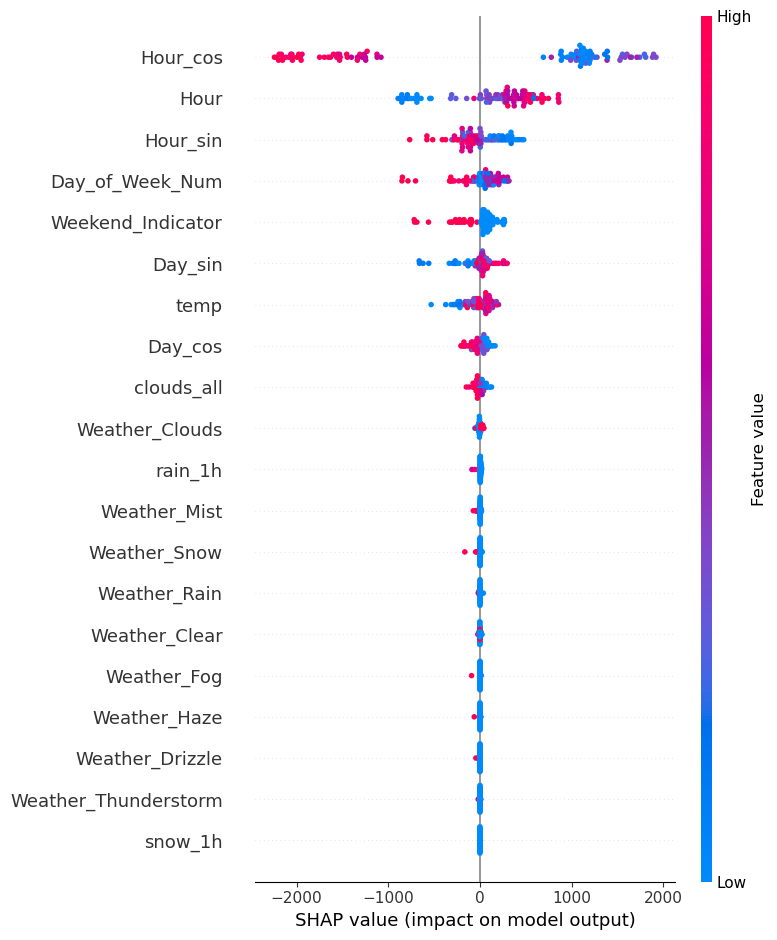

In [48]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X_shap.columns
)

In [49]:
shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

shap_importance.head(10)

,Feature,Mean_Absolute_SHAP
4,Hour_cos,1439.533885
0,Hour,440.582568
3,Hour_sin,192.854294
1,Day_of_Week_Num,151.697265
2,Weekend_Indicator,132.125936
5,Day_sin,110.129872
8,temp,105.044175
6,Day_cos,68.557186
11,clouds_all,36.754705
13,Weather_Clouds,12.800894


In [50]:
import mlflow

print("MLflow imported successfully.")

MLflow imported successfully.


In [52]:
from pathlib import Path
import mlflow

# Location for the local MLflow database
mlflow_db = Path(
    "../mlflow/mlflow.db"
).resolve()

mlflow_db.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Use SQLite instead of the old filesystem tracking backend
mlflow.set_tracking_uri(
    f"sqlite:///{mlflow_db.as_posix()}"
)

# Create/select the experiment
mlflow.set_experiment(
    "traffic_ml_experiments"
)

print(
    "MLflow tracking location:",
    mlflow.get_tracking_uri()
)

2026/09/14 15:48:45 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/14 15:48:45 INFO mlflow.store.db.utils: Updating database tables
2026/09/14 15:48:49 INFO mlflow.tracking.fluent: Experiment with name 'traffic_ml_experiments' does not exist. Creating a new experiment.


MLflow tracking location: sqlite:///C:/Users/hengc/OneDrive/Documents/AI ML Data Science Programme/Capstone/Capstone Work/Smart-City-Traffic-Intelligence-Local/Smart-City-Traffic-Intelligence/part3_machine_learning/mlflow/mlflow.db


In [55]:
from pathlib import Path

artifact_dir = Path.home() / "mlflow_artifacts"

artifact_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Short artifact location:")
print(artifact_dir)

Short artifact location:
C:\Users\hengc\mlflow_artifacts


In [56]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

experiment_name = "traffic_ml_experiments_v2"

existing_experiment = client.get_experiment_by_name(
    experiment_name
)

if existing_experiment is None:
    experiment_id = client.create_experiment(
        name=experiment_name,
        artifact_location=artifact_dir.as_uri()
    )
else:
    experiment_id = existing_experiment.experiment_id

mlflow.set_experiment(
    experiment_id=experiment_id
)

print("Experiment ID:", experiment_id)
print("Artifact location:", artifact_dir)

Experiment ID: 2
Artifact location: C:\Users\hengc\mlflow_artifacts


In [57]:
import mlflow
import mlflow.sklearn

with mlflow.start_run(
    run_name="random_forest_regressor_v1"
):

    mlflow.log_param(
        "n_estimators",
        100
    )

    mlflow.log_param(
        "random_state",
        42
    )

    mlflow.log_metric(
        "MAE",
        rf_reg_mae
    )

    mlflow.log_metric(
        "R2",
        rf_reg_r2
    )

    mlflow.sklearn.log_model(
        sk_model=random_forest_reg,
        name="model"
    )

print("Random Forest experiment logged to MLflow.")

Random Forest experiment logged to MLflow.


In [59]:
runs.columns.tolist()

['run_id',
 'experiment_id',
 'status',
 'artifact_uri',
 'start_time',
 'end_time',
 'metrics.MAE',
 'metrics.R2',
 'params.n_estimators',
 'params.random_state',
 'tags.mlflow.runName',
 'tags.mlflow.source.name',
 'tags.mlflow.source.type',
 'tags.mlflow.user']

In [60]:
runs[
    [
        "tags.mlflow.runName",
        "params.n_estimators",
        "params.random_state",
        "metrics.MAE",
        "metrics.R2"
    ]
]

,tags.mlflow.runName,params.n_estimators,params.random_state,metrics.MAE,metrics.R2
0,random_forest_regressor_v1,100,42,271.256867,0.944233


In [61]:
with mlflow.start_run(
    run_name="linear_regression_baseline"
):

    mlflow.log_param(
        "model_type",
        "Linear Regression"
    )

    mlflow.log_metric(
        "MAE",
        linear_mae
    )

    mlflow.log_metric(
        "R2",
        linear_r2
    )

print("Linear Regression experiment logged to MLflow.")

Linear Regression experiment logged to MLflow.


In [62]:
with mlflow.start_run(
    run_name="neural_network_regressor_v1"
):

    mlflow.log_param(
        "hidden_layers",
        "64,32"
    )

    mlflow.log_param(
        "activation",
        "relu"
    )

    mlflow.log_param(
        "max_iter",
        300
    )

    mlflow.log_param(
        "early_stopping",
        True
    )

    mlflow.log_metric(
        "MAE",
        nn_mae
    )

    mlflow.log_metric(
        "R2",
        nn_r2
    )

print("Neural Network experiment logged to MLflow.")

Neural Network experiment logged to MLflow.


In [63]:
runs = mlflow.search_runs(
    experiment_ids=[experiment_id]
)

mlflow_comparison = runs[
    [
        "tags.mlflow.runName",
        "metrics.MAE",
        "metrics.R2"
    ]
].sort_values(
    "metrics.R2",
    ascending=False
)

mlflow_comparison

,tags.mlflow.runName,metrics.MAE,metrics.R2
2,random_forest_regressor_v1,271.256867,0.944233
0,neural_network_regressor_v1,294.528508,0.940257
1,linear_regression_baseline,813.474603,0.725961


In [64]:
travel_profile = (
    df.groupby(
        ["Day_Type", "Hour"]
    )["traffic_volume"]
    .mean()
    .reset_index()
    .rename(
        columns={
            "traffic_volume": "Average_Traffic"
        }
    )
)

travel_profile.head(10)

,Day_Type,Hour,Average_Traffic
0,Weekday,0,651.686903
1,Weekday,1,396.913043
2,Weekday,2,301.982818
3,Weekday,3,362.289835
4,Weekday,4,832.661096
5,Weekday,5,2701.296703
6,Weekday,6,5365.983210
7,Weekday,7,6030.413559
8,Weekday,8,5503.497970
9,Weekday,9,4895.269257


In [65]:
best_travel_hours = (
    travel_profile
    .sort_values(
        ["Day_Type", "Average_Traffic"],
        ascending=[True, True]
    )
    .groupby("Day_Type")
    .head(5)
)

best_travel_hours

,Day_Type,Hour,Average_Traffic
2,Weekday,2,301.982818
3,Weekday,3,362.289835
1,Weekday,1,396.913043
0,Weekday,0,651.686903
4,Weekday,4,832.661096
28,Weekend,4,375.420168
27,Weekend,3,393.611599
26,Weekend,2,611.171986
29,Weekend,5,639.237232
25,Weekend,1,805.717391


In [66]:
practical_travel_profile = travel_profile[
    travel_profile["Hour"].between(6, 22)
].copy()

practical_best_hours = (
    practical_travel_profile
    .sort_values(
        ["Day_Type", "Average_Traffic"],
        ascending=[True, True]
    )
    .groupby("Day_Type")
    .head(5)
)

practical_best_hours

,Day_Type,Hour,Average_Traffic
22,Weekday,22,2125.913104
21,Weekday,21,2673.042807
20,Weekday,20,2842.433004
19,Weekday,19,3297.120114
10,Weekday,10,4377.942436
30,Weekend,6,1089.100334
31,Weekend,7,1589.365894
32,Weekend,8,2338.578073
46,Weekend,22,2384.368607
45,Weekend,21,2658.445242


In [67]:
weather_travel_profile = (
    df[df["Hour"].between(6, 22)]
    .groupby(
        [
            "Day_Type",
            "weather_main",
            "Hour"
        ]
    )["traffic_volume"]
    .agg(
        Average_Traffic="mean",
        Observations="count"
    )
    .reset_index()
)

weather_travel_profile.head(10)

,Day_Type,weather_main,Hour,Average_Traffic,Observations
0,Weekday,Clear,6,5441.788835,412
1,Weekday,Clear,7,6003.265244,328
2,Weekday,Clear,8,5518.928339,307
3,Weekday,Clear,9,4964.534682,346
4,Weekday,Clear,10,4468.280112,357
5,Weekday,Clear,11,4734.624642,349
6,Weekday,Clear,12,4949.782857,350
7,Weekday,Clear,13,4950.310241,332
8,Weekday,Clear,14,5259.301587,315
9,Weekday,Clear,15,5673.595611,319


In [68]:
reliable_weather_profile = weather_travel_profile[
    weather_travel_profile["Observations"] >= 20
].copy()

print(
    "Original combinations:",
    len(weather_travel_profile)
)

print(
    "Reliable combinations:",
    len(reliable_weather_profile)
)

reliable_weather_profile.head(10)

Original combinations: 322
Reliable combinations: 243


,Day_Type,weather_main,Hour,Average_Traffic,Observations
0,Weekday,Clear,6,5441.788835,412
1,Weekday,Clear,7,6003.265244,328
2,Weekday,Clear,8,5518.928339,307
3,Weekday,Clear,9,4964.534682,346
4,Weekday,Clear,10,4468.280112,357
5,Weekday,Clear,11,4734.624642,349
6,Weekday,Clear,12,4949.782857,350
7,Weekday,Clear,13,4950.310241,332
8,Weekday,Clear,14,5259.301587,315
9,Weekday,Clear,15,5673.595611,319


In [69]:
weather_recommendations = (
    reliable_weather_profile
    .sort_values(
        ["Day_Type", "weather_main", "Average_Traffic"],
        ascending=[True, True, True]
    )
    .groupby(
        ["Day_Type", "weather_main"]
    )
    .head(3)
)

weather_recommendations.head(15)

,Day_Type,weather_main,Hour,Average_Traffic,Observations
16,Weekday,Clear,22,2222.526749,486
15,Weekday,Clear,21,2743.681604,424
14,Weekday,Clear,20,2925.327411,394
33,Weekday,Clouds,22,2146.462287,411
32,Weekday,Clouds,21,2730.959831,473
31,Weekday,Clouds,20,2908.088346,532
50,Weekday,Drizzle,22,1997.800000,65
49,Weekday,Drizzle,21,2546.316667,60
48,Weekday,Drizzle,20,2740.870370,54
55,Weekday,Fog,10,4278.791667,24


In [72]:
def recommend_travel_time(day_type, weather):
    matches = weather_recommendations[
        (weather_recommendations["Day_Type"] == day_type)
        & (weather_recommendations["weather_main"] == weather)
    ].sort_values("Average_Traffic")

    if matches.empty:
        return (
            "No reliable historical recommendation "
            "is available for this combination."
        )

    best = matches.iloc[0]

    start_hour = int(best["Hour"])
    end_hour = start_hour + 1
    avg_traffic = best["Average_Traffic"]

    recommendation = (
        f"For a {day_type.lower()} journey in {weather.lower()} weather, "
        f"consider travelling between "
        f"{start_hour:02d}:00 and {end_hour:02d}:00, "
        f"when historical traffic volume averages about "
        f"{avg_traffic:.0f} vehicles."
    )

    return recommendation

In [73]:
recommend_travel_time(
    "Weekday",
    "Clear"
)

'For a weekday journey in clear weather, consider travelling between 22:00 and 23:00, when historical traffic volume averages about 2223 vehicles.'

In [74]:
import joblib
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(
    parents=True,
    exist_ok=True
)

model_bundle = {
    "model": random_forest_reg,
    "feature_columns": feature_columns,
    "version": "v1",
    "MAE": rf_reg_mae,
    "R2": rf_reg_r2
}

model_path = model_dir / "traffic_volume_rf_v1.joblib"

joblib.dump(
    model_bundle,
    model_path
)

print("Model saved to:")
print(model_path.resolve())

Model saved to:
C:\Users\hengc\OneDrive\Documents\AI ML Data Science Programme\Capstone\Capstone Work\Smart-City-Traffic-Intelligence-Local\Smart-City-Traffic-Intelligence\part3_machine_learning\models\traffic_volume_rf_v1.joblib


In [75]:
model_versions = pd.DataFrame({
    "Version": [
        "v0",
        "v1",
        "v2"
    ],
    "Model": [
        "Linear Regression",
        "Random Forest Regressor",
        "Neural Network"
    ],
    "MAE": [
        linear_mae,
        rf_reg_mae,
        nn_mae
    ],
    "R2": [
        linear_r2,
        rf_reg_r2,
        nn_r2
    ],
    "Status": [
        "Baseline",
        "Selected for Deployment",
        "Candidate"
    ]
})

model_versions.round(4)

,Version,Model,MAE,R2,Status
0,v0,Linear Regression,813.4746,0.7260,Baseline
1,v1,Random Forest Regressor,271.2569,0.9442,Selected for Deployment
2,v2,Neural Network,294.5285,0.9403,Candidate


In [77]:
monitor_predictions = random_forest_reg.predict(
    X_test_reg
)

monitor_mae = mean_absolute_error(
    y_test_reg,
    monitor_predictions
)

print(
    "Current monitoring MAE:",
    round(monitor_mae, 2)
)

Current monitoring MAE: 271.26


In [78]:
baseline_mae = rf_reg_mae

alert_threshold = baseline_mae * 1.20

if monitor_mae <= alert_threshold:
    monitoring_status = "PASS / Normal"
else:
    monitoring_status = "ALERT / Requires investigation"

print("Baseline MAE:", round(baseline_mae, 2))
print("Alert threshold:", round(alert_threshold, 2))
print("Current MAE:", round(monitor_mae, 2))
print("Monitoring status:", monitoring_status)

Baseline MAE: 271.26
Alert threshold: 325.51
Current MAE: 271.26
Monitoring status: PASS / Normal


In [79]:
simulated_future_mae = 350

if simulated_future_mae <= alert_threshold:
    simulated_status = "PASS / Normal"
else:
    simulated_status = "ALERT / Requires investigation"

print(
    "Simulated future MAE:",
    simulated_future_mae
)

print(
    "Alert threshold:",
    round(alert_threshold, 2)
)

print(
    "Simulated monitoring status:",
    simulated_status
)

Simulated future MAE: 350
Alert threshold: 325.51
Simulated monitoring status: ALERT / Requires investigation


In [80]:
from pathlib import Path
import joblib

model_path = Path("../models/traffic_volume_rf_v1.joblib")

# Load the existing model bundle
model_bundle = joblib.load(model_path)

# Save the same model again with compression
joblib.dump(
    model_bundle,
    model_path,
    compress=3
)

size_mb = model_path.stat().st_size / (1024 * 1024)

print(f"Compressed model size: {size_mb:.2f} MB")

Compressed model size: 59.05 MB
